# PyTorch
PyTorch jest frameworkiem do Deep Learning.

Relacja między ML i DL:
AI -> ML -> DL 

PyTorch pozwala na tworzenie i trenowanie sieci neuronowych do różnych zastosowań. Teroetycznie można w nim realizować również bardziej podstawowe modele, jednak i tak sprowadza się to do stworzenia prostej sieci neuronowej, symulującej zachowanie np. KNN-a, Regresji, czy innego podejścia.

Moduł trzeba oczywiście zainstalować. Dodatkowo, jeżeli chcemy wykorzystać GPU do obliczeń (zakładając, że mamy kartę kompatybilną z CUDA), wymaga to zainstalowania dodatkowego narzędzia od Nvidi.

W celu sprawdzenia czy całość działa, można uruchomić poniższy fragment kodu.

In [2]:
import torch
if torch.cuda.is_available():
    print("GPU: {} is available.".format(torch.cuda.get_device_name(0)))
else:
    print("No GPU available. Training will run on CPU.")

GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU is available.


Później można podpiąć urządzenie pod obliczenia. Warto od razu wrzucić obsługę sytuacji, gdy GPU acceleration nie jest dostępne (wtedy obliczenia będą się wykonywać na CPU).

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


PyTorch operuje na Tensorach - wielowymiarowych macierzach. W ramach działania programu na tensorach wykonywane będą podstawowe operacje:
 - Indeksowanie
 - Slicing
 - Przekształcanie (reshape)
Mamy też metody umożliwiające np. efektywne operacje na macierzach oraz dynamicznego rozszerzania rozmiarów macierzy, np. w celu wykonywania operacji na tensorach o różnych rozmiarach.

In [8]:
import torch

tensor = torch.tensor([[1, 2], [3, 4], [5, 6]]) #Tworzenie tensora
print("Original tensor: {}".format(tensor))
#Operacje
element = tensor[1, 0]
print("Indexed Element (Row 1, Column 0): {}".format(element))  
slice_tensor = tensor[:2, :]
print("Sliced Tensor (First two rows): \n{}".format(slice_tensor))
reshaped_tensor = tensor.view(2, 3)
print("Reshaped Tensor (2x3): \n{}".format(reshaped_tensor))
#Metody
print("==========================")
tensor_a = torch.tensor([[1, 2, 3], [4, 5, 6]])
tensor_b = torch.tensor([[10, 20, 30]]) 
print("Original tensors: \n{}\n{}".format(tensor_a, tensor_b))

broadcasted_result = tensor_a + tensor_b 
print("Broadcasted Addition Result: \n{}".format(broadcasted_result))

matrix_multiplication_result = torch.matmul(tensor_a, tensor_a.T)
print("Matrix Multiplication Result (tensor_a * tensor_a^T): \n{}".format(matrix_multiplication_result))

Original tensor: tensor([[1, 2],
        [3, 4],
        [5, 6]])
Indexed Element (Row 1, Column 0): 3
Sliced Tensor (First two rows): 
tensor([[1, 2],
        [3, 4]])
Reshaped Tensor (2x3): 
tensor([[1, 2, 3],
        [4, 5, 6]])
Original tensors: 
tensor([[1, 2, 3],
        [4, 5, 6]])
tensor([[10, 20, 30]])
Broadcasted Addition Result: 
tensor([[11, 22, 33],
        [14, 25, 36]])
Matrix Multiplication Result (tensor_a * tensor_a^T): 
tensor([[14, 32],
        [32, 77]])


## Wykorzystanie GPU Acceleration
Jak wspomniano wcześniej, jeżeli mamy kompatybilną kartę graficzną i możemy włączyć wykonywanie obliczeń na karcie, zwykle znacznie przyspieszy to obliczenia. W tym celu należy przenieść tensory na GPU.

### UWAGA! 
Poniższy kod nie działa w jupyter dla Python 3.13+ z CUDA 13.0, trzeba go przekleić do osobnego skryptu.

In [ ]:
import torch

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print('Using device: {}'.format(device))


if device=='cuda':
    torch.cuda.init()

tensor_size = (10000, 10000)  
a = torch.randn(tensor_size, device=device)  
b = torch.randn(tensor_size, device=device)  

c = a + b  

memoryAllocated = torch.cuda.memory_allocated(device) / (1024 ** 2)
memoryReserved = torch.cuda.memory_reserved(device) / (1024 ** 2)

print("Result shape (moved to CPU for printing):", c.cpu().shape)

print("Current GPU memory usage:")
print("Allocated: {} MB".format(memoryAllocated))
print("Cached: {} MB".format(memoryReserved))

Jako że pracujemy z sieciami neuronowymi, jako przykład można zrobić klasyfikację obrazu z wykorzystaniem konwolucyjnej sieci neuronowej. 

Zaczynamy od importu, ustawienia kontekstu i globalnych parametrów, w celu uniknięcia potencjalnych błędów, np. przy ściąganiu danych.

In [19]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import ssl

ssl._create_default_https_context = ssl._create_unverified_context
plt.rcParams['figure.figsize'] = 14, 6

PyTorch umożliwia zarówno ustawienie podstawowych parametrów transformacji/skalowania, jak również ściągnięcie standardowych zbiorów danych. W tym wypadku korzystamy ze zbioru CIFAR-10. 

W pierwszej kolejności ustawiamy normalizację na odchylenie standardowe i średnią 0.5, później ściągamy zbiór danych. 

In [20]:
normalize_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])

train_dataset = torchvision.datasets.CIFAR10(
    root="./CIFAR10/train", train=True, transform=normalize_transform, download=True)
test_dataset = torchvision.datasets.CIFAR10(
    root="./CIFAR10/test", train=False, transform=normalize_transform, download=True)

100%|██████████| 170M/170M [00:09<00:00, 18.9MB/s] 
100%|██████████| 170M/170M [00:09<00:00, 18.5MB/s] 


Kolejnym ułatwieniem są data loader-y. Umożliwiają one sprawne operowanie na danych i np. szybkie ich przetasowywanie i iterowanie podczas trenowania sieci. 

W tym wypadku ustawimy rozmiar serii (batch) na 128 i utworzymy data loader zarówno dla zbioru treningowego jak i testowego. 

In [21]:
batch_size = 128
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size)

Przy pracy z obrazami, zwłaszcza jeżeli nie znamy dobrze zbioru danych, dobrze jest zwizualizować sobie ten zbiór i np. wyświetlić przykładowe obrazy, żeby sprawdzić z jakimi danymi mamy do czynienia. 

W tym wypadku wyświetlimy 100 obrazów w siatce 10x10.

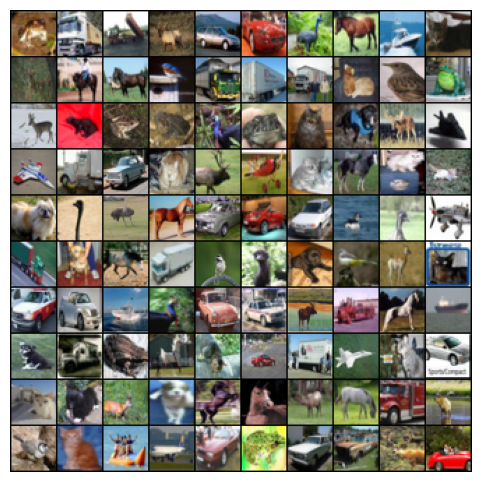

In [23]:
dataiter = iter(train_loader)
images, labels = next(dataiter)
plt.imshow(np.transpose(torchvision.utils.make_grid(
    images[:100], normalize=True, padding=1, nrow=10).numpy(), (1, 2, 0)))
plt.axis('off')
plt.show()

Kolejna rzecz, która nas interesuje, to jak rozkładają się obrazki w poszczególnych klasach - w ramach przypomnienia, do trenowania sieci chcemy mieć możliwie zbalansowany zbiór, w innym wypadku model może się przekaszać w stronę lepiej reprezentowanej klasy (bias). 

W celu wizualizacji musimy zebrać wszystkie klasy oraz zliczyć ich wstąpienia w zbiorze danych.

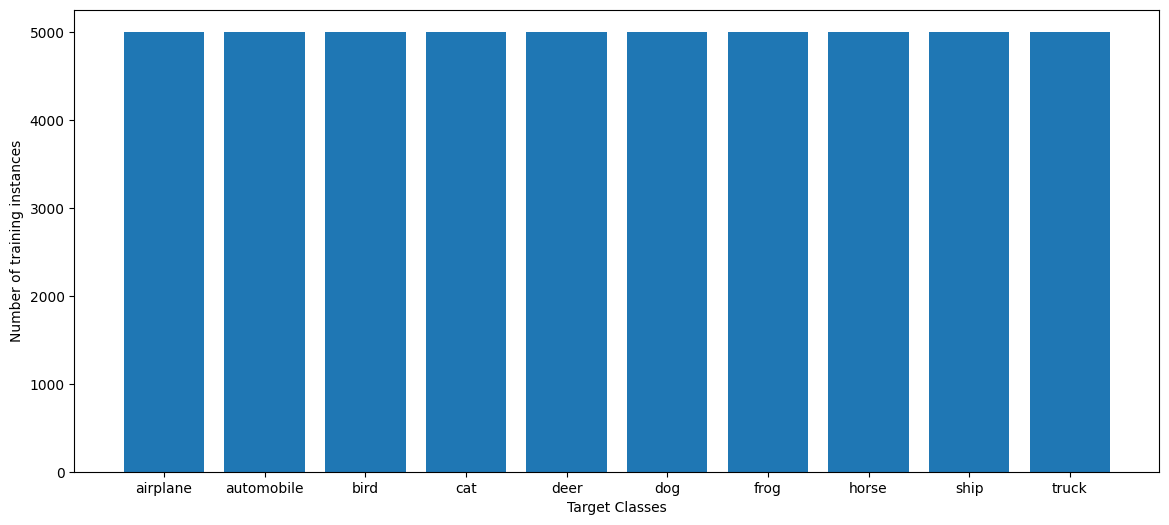

In [24]:
classes = []
for batch_idx, data in enumerate(train_loader):
    x, y = data
    classes.extend(y.tolist())

unique, counts = np.unique(classes, return_counts=True)
names = list(test_dataset.class_to_idx.keys())
plt.bar(names, counts)
plt.xlabel("Target Classes")
plt.ylabel("Number of training instances")
plt.show()

Jak widzimy, zbiór jest bardzo zrównoważony, z tym więc nie będziemy mieli problemu. 

Kolejnym krokiem jest zbudowanie architektury naszej sieci. Budujemy sieć CNN, która będzie miała:
 - 3 zestawy warstw: convolution, activation(ReLU) i max pooling
 - wygładzanie parametrów oraz 2 w pełni połączone warstwy (fully connected layers)
 - warstwę wyjściową rozpoznającą 10 klas ze zbioru danych

In [25]:
class CNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.model = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=3, out_channels=32,
                            kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),
            torch.nn.Conv2d(in_channels=32, out_channels=64,
                            kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),
            torch.nn.Conv2d(in_channels=64, out_channels=64,
                            kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),
            torch.nn.Flatten(),
            torch.nn.Linear(64 * 4 * 4, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.model(x)

Kolejnym krokiem jest skonfigurowanie procesu trnowania sieci. W pierwszej kolejności wybieramy device na którym będziemy pracować (GPU jeżeli dostępne, CPU w przeciwnym przypadku). Później podpinamy naszą sieć do wybranego urządzenia, ustawiamy ilość epok trenowania sieci, oraz parametry trenowania.

### Uwaga!
Tutaj będzie ten sam problem co przy poprzednim wykorzystaniu GPU - w razie czego całość przykładu jest umieszczona w skrypcie PyTorchExampleCNN.py i można to uruchomić stamtąd. W przykładzie wyłączone są elementy wizualizacyjne i od razu przechodzi on do ustawienia i trenowania modelu.

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = CNN().to(device)

num_epochs = 50
learning_rate = 0.001
weight_decay = 0.01
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(), lr=learning_rate, weight_decay=weight_decay)

Po ustawieniu parametrów zostaje już tylko wytrenowanie modelu i zapisanie parametrów podczas całego procesu. Warto również zwizualizować krzywą uczenia, by zobaczyć jak zmienia się "training loss" w trakcie kolejnych epok (Obrazek TrainingLoss.png). 

In [ ]:
train_loss_list = []
for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}:', end=' ')
    train_loss = 0
    model.train()
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss_list.append(train_loss / len(train_loader))
    print(f"Training loss = {train_loss_list[-1]}")

plt.plot(range(1, num_epochs + 1), train_loss_list)
plt.xlabel("Number of epochs")
plt.ylabel("Training loss")
plt.show()

Po wytrenowaniu modelu możemy przełączyć go w tryb ewaluacji i wyłączyć wyliczanie gradientów. Następnie dla każdej serii danych sprawdzamy wyniki - ilość poprawnie/niepoprawnie zaklasyfikowanych przykładów. Interesuje nas całkowita dokładność klasyfikacji. 

In [ ]:
test_acc = 0
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        y_true = labels.to(device)
        outputs = model(images)
        _, y_pred = torch.max(outputs.data, 1)
        test_acc += (y_pred == y_true).sum().item()

print(f"Test set accuracy = {100 * test_acc / len(test_dataset)} %")

Wychodzi dokładność w okolicy 72% - nie najgorzej biorąc pod uwagę krótki czas trenowania. 

Raz wytrenowany model można zapisać i następnie wykorzystać raz wytrenowane wagi ponownie, bez konieczności ich trenowania.

In [ ]:
#zapisanie modelu
torch.save(model, "ModelExample")

#załadowanie modelu
newModel = torch.load("ModelExample", weights_only=False)
test_acc = 0
newModel.eval()

#Ta sama ewaluacja co poprzednio
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        y_true = labels.to(device)
        outputs = newModel(images)
        _, y_pred = torch.max(outputs.data, 1)
        test_acc += (y_pred == y_true).sum().item()

print(f"Test set accuracy = {100 * test_acc / len(test_dataset)} %")

Ogólnie trenowanie modeli Deep Learning jest pracochłonnym procesem, wymagającym dużych ilości danych, jak również wielu iteracji. Mogłoby się przy tej okazji wydawać, że np. więcej epok skutkowałoby lepszym modelem i często jest to prawda, zakładając że mamy do czynienia z odpowiednio dużym zbiorem danych. W przypadku naszego zbioru, niestety nie podniesie to jakości modelu.

Załączony przykład: training loss dla modelu trenowanego przez 100 epok - plik txt z wartościami oraz wykres TrainingLoss100Epochs.png obrazują proces uczenia, dodatkowo załączam również wytrenowany model. Niestety, jego dokładność również plasuje się w okolicy 72%, a więc praktycznie taki sam wynik, przy dwukrotnie dłuższym czasie trenowania. Dodatkowo, należy pamiętać, że wydłużając trenowanie modelu zwiększamy ryzyko przetrenowania. 

## Pretrenowane modele

Biorąc pod uwagę możliwość zapisania/wczytania modelu z wagami, często lepiej jest skożystać z istniejącego modelu, trenowanego na podobnym zbiorze danych i dotrenować go na naszych danych. Wymaga to mniejszych ilości przykładów, jak również zwykle daje lepsze efekty niż trenowanie modelu od zera na mniejszym zbiorze. 

Do podanego przykładu możnaby np. wykorzystać następujące, istniejące sieci, służące do rozpoznawania obrazów:
 - ResNet
 - VGG
 - EfficientNet
 - AlexNet
 Oraz inne.

 Przy pracy z modelami DL do różnych zastosowań, naszym pierwszym krokiem zawsze powinno być sprawdzenie istniejących rozwiązań.